In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [38]:
plt.style.use('/home/joliveira/Documents/franck-hertz/joao.mplstyle')
# --- DEFINIÇÃO DO TEMA GLOBAL USANDO rcParams ---
plt.rcParams['figure.figsize'] = (20, 12) # Define o tamanho da figura para 10x6 polegadas
plt.rcParams['font.size'] = 14           # Define o tamanho da fonte geral como 14
plt.rcParams['axes.titlesize'] = 25      # Tamanho da fonte do título
plt.rcParams['axes.labelsize'] = 20      # Tamanho da fonte dos rótulos dos eixos
plt.rcParams['axes.grid'] = True        # Habilita/desabilita a grade em todos os gráficos
plt.rcParams['grid.linestyle'] = '-'      # Estilo da grade: tracejado
plt.rcParams['grid.alpha'] = 0.6         # Transparência da grade
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['savefig.dpi'] = 700        # Alta resolução para salvar as figuras
plt.rcParams['lines.linestyle'] = '-'    # Linha sólida
plt.rcParams['lines.linewidth'] = 3   # Espessura da linha
# plt.rcParams['figure.facecolor'] = 'none'   # Fundo da figura transparente
# plt.rcParams['axes.facecolor']   = 'none'   # Fundo dos eixos transparente
# plt.rcParams['savefig.facecolor'] = 'none'  # Ao salvar, mantém transparente
# plt.rcParams['savefig.transparent'] = True  # Salva figuras com fundo transparente
plt.rcParams['xtick.labelsize'] = 16    # Tamanho dos rótulos do eixo x
plt.rcParams['ytick.labelsize'] = 16    # Tamanho dos rótulos do eixo y
# ---------------------------------------------------

Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 617 ('view raw')
Missing colon in file '/home/joliveira/Documents/franck-hertz/joao.mplstyle', line 618 ('matplotlibrc hosted with ❤ by GitHub')


In [39]:
import pandas as pd
import os

def subtrair_primeira_coluna(caminho_arquivo, valor_subtrair):
    """
    Lê um arquivo de duas colunas, subtrai um valor fixo da primeira coluna
    e salva o resultado sobrescrevendo o arquivo original.
    O arquivo original é renomeado para nome.old.

    Parâmetros:
    -----------
    caminho_arquivo : str
        Caminho completo para o arquivo de entrada.
    valor_subtrair : float
        Valor que será subtraído da primeira coluna.
    """

    # Garante que o arquivo existe
    if not os.path.exists(caminho_arquivo):
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_arquivo}")

    # Lê o arquivo conforme o formato fornecido
    df_dados = pd.read_csv(
        caminho_arquivo,
        sep=r"\s+",
        header=None,
        names=["Potencial (V)", "Corrente (uA)"]
    )

    # Subtrai o valor fixo da primeira coluna
    df_dados["Potencial (V)"] = df_dados["Potencial (V)"] - valor_subtrair

    # Gera o nome do arquivo original com sufixo ".old"
    caminho_backup = caminho_arquivo + ".old"

    # Renomeia o arquivo original
    os.rename(caminho_arquivo, caminho_backup)

    # Salva o novo arquivo com o nome original
    df_dados.to_csv(
        caminho_arquivo,
        sep="\t",
        header=False,
        index=False,
        float_format="%.6f"
    )

    print(f"Arquivo modificado salvo em: {caminho_arquivo}")
    print(f"Arquivo original foi renomeado para: {caminho_backup}")


In [40]:
# subtrair_primeira_coluna("Dados experimentais 23.10.2025 (Com fator de escala)/m1-i-T_120.txt", 3.82)


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import os



def plot_medidas_ionizacao(temperatura, pasta_dados, pasta_excel, salvar=False, pasta_saida=None):
    """
    Lê os arquivos de medidas de ionização para uma dada temperatura,
    aplica fator de escala e normalização max-min, e plota a corrente.

    Parâmetros:
    - temperatura (int|str): ex: 110
    - pasta_dados (str): pasta com o arquivo 'm1-i-T_<temperatura>.txt'
    - pasta_excel (str): pasta com o arquivo 'Medidas Ionização <temperatura>°C (Com fator de escala).xlsx'
    - salvar (bool): se True, salva o gráfico automaticamente com nome 'Ionizacao_<temperatura>C.png'
    - pasta_saida (str|None): pasta onde salvar o gráfico, obrigatória se salvar=True
    """

    # --- Montar nomes de arquivos ---
    nome_arquivo_dados = f"m1-i-T_{temperatura}.txt"
    nome_arquivo_excel = f"Medidas Ionização {temperatura}°C (Com fator de escala).xlsx"
    nome_saida = f"Ionizacao_{temperatura}C.png"

    caminho_dados = os.path.join(pasta_dados, nome_arquivo_dados)
    caminho_excel = os.path.join(pasta_excel, nome_arquivo_excel)

    # --- Ler Excel ---
    if not os.path.isfile(caminho_excel):
        raise FileNotFoundError(f"Arquivo Excel não encontrado: {caminho_excel}")

    df_excel = pd.read_excel(caminho_excel)
    df_excel.columns = [str(c).strip() for c in df_excel.columns]

    # Procurar coluna de escala
    escala_col = None
    for c in df_excel.columns:
        if "escala" in c.lower():
            escala_col = c
            break

    if escala_col is None:
        raise KeyError(f"Coluna 'Escala' não encontrada. Colunas disponíveis: {df_excel.columns.tolist()}")

    # Extrair valor de escala
    escala = pd.to_numeric(df_excel[escala_col], errors="coerce").dropna().iloc[0]

    # --- Ler arquivo de dados ---
    if not os.path.isfile(caminho_dados):
        raise FileNotFoundError(f"Arquivo de dados não encontrado: {caminho_dados}")

    df_dados = pd.read_csv(
        caminho_dados,
        sep=r"\s+",
        header=None,
        names=["Potencial (V)", "Corrente (uA)"],
        engine="python"
    )

    # Converter para numérico e aplicar fator de escala
    df_dados["Potencial (V)"] = pd.to_numeric(df_dados["Potencial (V)"].astype(str).str.replace(",", "."), errors="coerce")
    df_dados["Corrente (uA)"] = pd.to_numeric(df_dados["Corrente (uA)"].astype(str).str.replace(",", "."), errors="coerce")
    df_dados = df_dados.dropna()
    df_dados["Corrente (uA)"] *= escala

    # --- Normalização Max-Min ---
    i_min = df_dados["Corrente (uA)"].min()
    i_max = df_dados["Corrente (uA)"].max()
    df_dados["Corrente Normalizada"] = (df_dados["Corrente (uA)"] - i_min) / (i_max - i_min)

    # --- Plot ---
    # plt.yscale('log')
    plt.plot(
        df_dados["Potencial (V)"],
        df_dados["Corrente Normalizada"],
        linestyle="-",
        marker="D",
        markersize=6,
        markerfacecolor="red",
        markeredgewidth=0,  # sem borda
        markevery=50
    )
    plt.title(f"Medidas de Ionização - {temperatura}°C (Normalizado)")
    plt.xlabel("Potencial (V)")
    plt.ylabel("Corrente Normalizada")
    plt.grid(True, linestyle="-", alpha=0.6)

    # --- Adicionar anotação do valor máximo (no canto superior esquerdo) ---
    i_max_amp = i_max * 1e-6  # converter μA → A
    plt.annotate(
        f"Corrente máxima: {i_max_amp:.2e} (A)",
        xy=(0.01, 0.99),
        xycoords="axes fraction",
        xytext=(10, -10),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=20,  
        bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7)
    )

    plt.tight_layout()

    # --- Salvar se for solicitado ---
    if salvar:
        if pasta_saida is None:
            raise ValueError("É necessário fornecer 'pasta_saida' quando salvar=True.")
        os.makedirs(pasta_saida, exist_ok=True)
        caminho_saida = os.path.join(pasta_saida, nome_saida)
        plt.savefig(caminho_saida, dpi=300)
        print(f"✅ Gráfico salvo em: {caminho_saida}")

    plt.show()
    return df_dados


✅ Gráfico salvo em: /home/joliveira/Documents/franck-hertz/Resultados/Ionizacao_120C.png


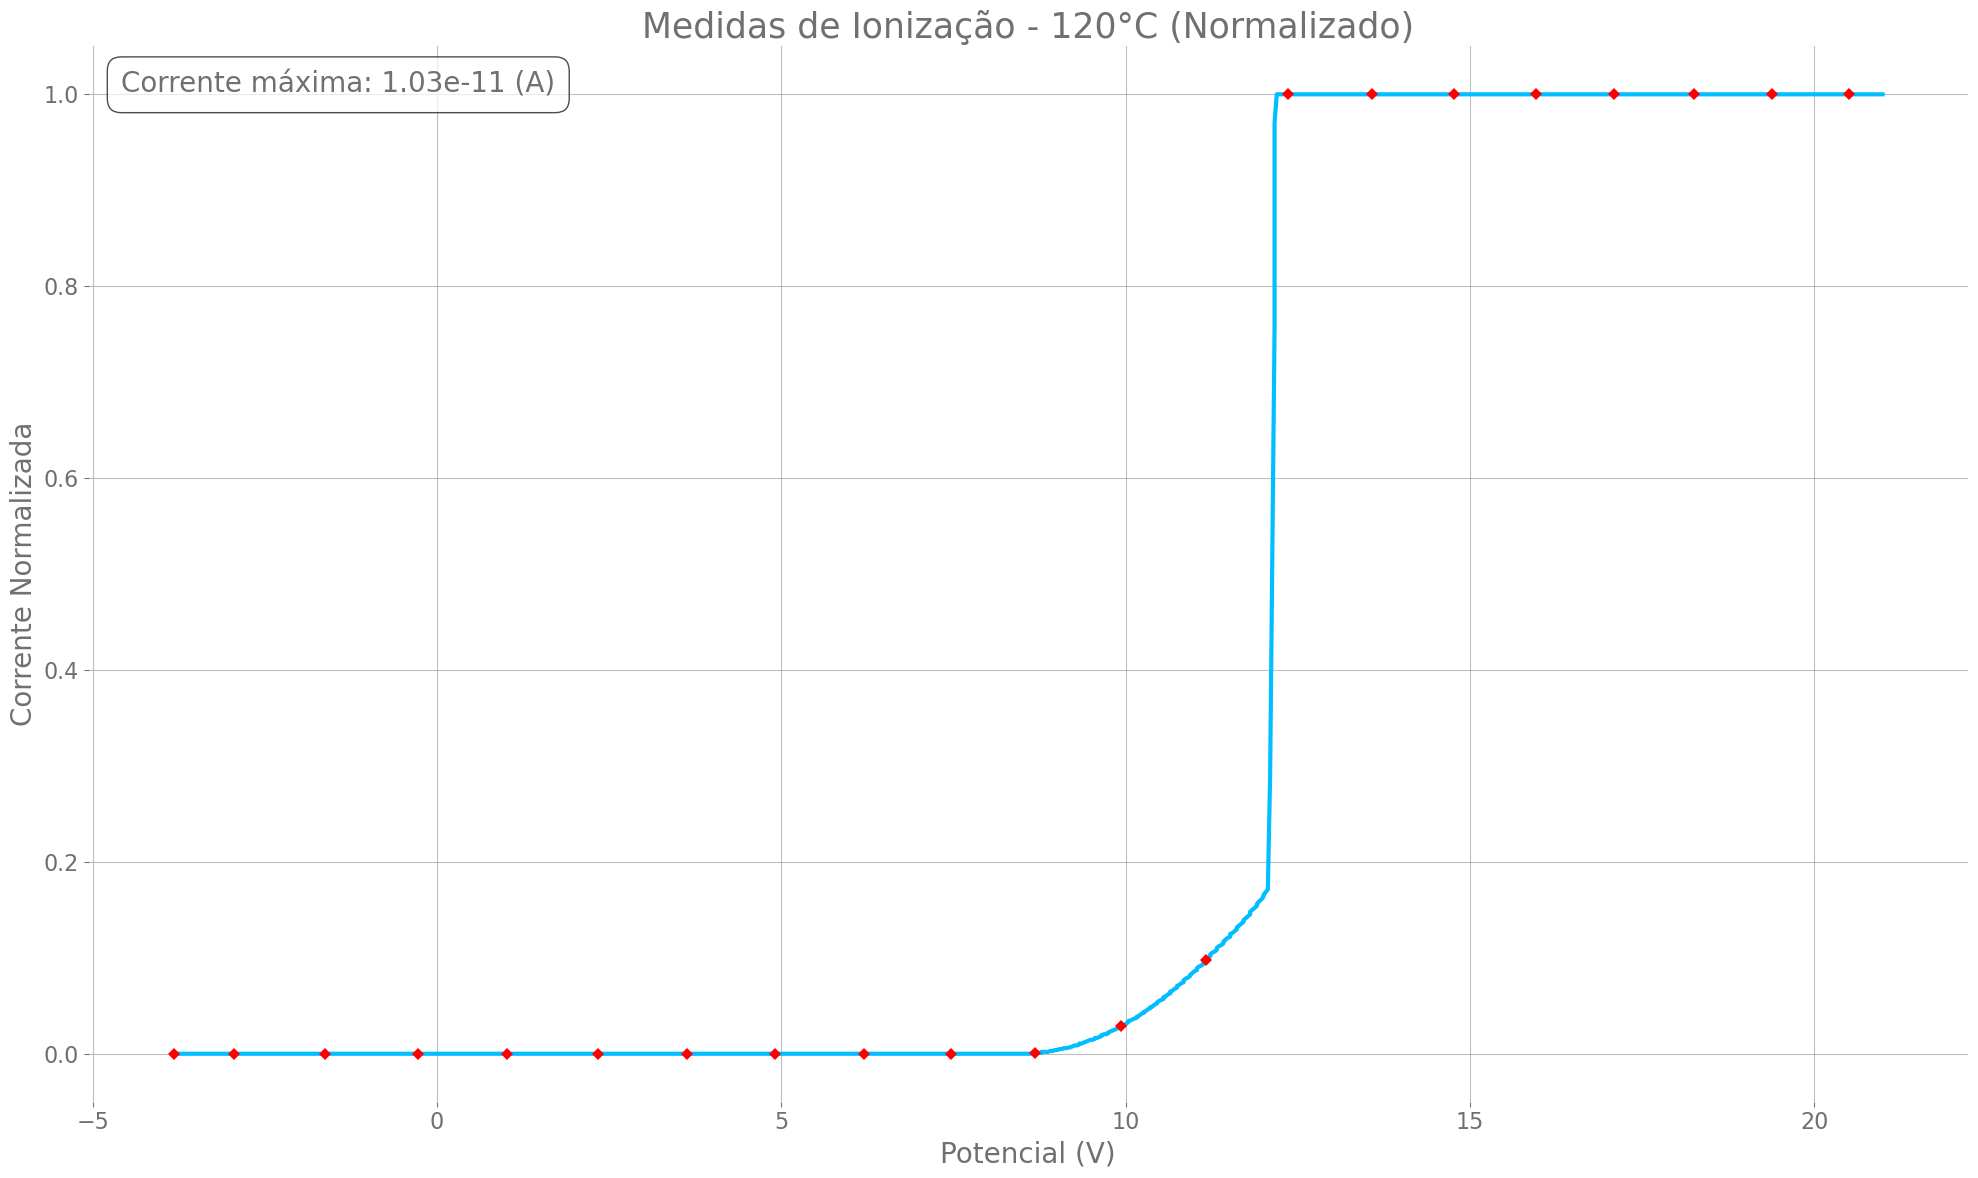

,Potencial (V),Corrente (uA),Corrente Normalizada
0,-3.82000,0.00000,0.0
1,-3.82000,0.00000,0.0
2,-3.82000,0.00000,0.0
3,-3.82000,0.00000,0.0
4,-3.82000,0.00000,0.0
...,...,...,...
1019,20.92496,0.00001,1.0
1020,20.92496,0.00001,1.0
1021,20.95718,0.00001,1.0
1022,20.98940,0.00001,1.0


In [42]:
plot_medidas_ionizacao(
    temperatura=120,
    pasta_dados="Dados experimentais 23.10.2025 (Com fator de escala)/",
    pasta_excel="/home/joliveira/Documents/franck-hertz/",
    salvar=True,
    pasta_saida="/home/joliveira/Documents/franck-hertz/Resultados/"
)


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import os


def plot_comparacao_deslocamento(temperatura, pasta_dados, pasta_excel, salvar=False, pasta_saida=None):
    """
    Lê os arquivos de medidas de ionização para uma dada temperatura,
    aplica fator de escala e normalização max-min, e plota as curvas
    comparando o arquivo original e o deslocado (_old).

    Parâmetros:
    - temperatura (int|str): ex: 120
    - pasta_dados (str): pasta com os arquivos de dados
    - pasta_excel (str): pasta com o arquivo Excel de fator de escala
    - salvar (bool): se True, salva o gráfico com nome 'Ionizacao_<temperatura>C_comparacao.png'
    - pasta_saida (str|None): pasta onde salvar o gráfico, obrigatória se salvar=True
    """

    # --- Montar nomes de arquivos ---
    nome_arquivo_dados = f"m1-i-T_{temperatura}.txt"
    nome_arquivo_old = f"m1-i-T_{temperatura}_old.txt"
    nome_arquivo_excel = f"Medidas Ionização {temperatura}°C (Com fator de escala).xlsx"
    nome_saida = f"Ionizacao_{temperatura}C_comparacao.png"

    caminho_dados = os.path.join(pasta_dados, nome_arquivo_dados)
    caminho_dados_old = os.path.join(pasta_dados, nome_arquivo_old)
    caminho_excel = os.path.join(pasta_excel, nome_arquivo_excel)

    # --- Ler Excel e obter fator de escala ---
    if not os.path.isfile(caminho_excel):
        raise FileNotFoundError(f"Arquivo Excel não encontrado: {caminho_excel}")

    df_excel = pd.read_excel(caminho_excel)
    df_excel.columns = [str(c).strip() for c in df_excel.columns]

    escala_col = next((c for c in df_excel.columns if "escala" in c.lower()), None)
    if escala_col is None:
        raise KeyError(f"Coluna 'Escala' não encontrada. Colunas disponíveis: {df_excel.columns.tolist()}")

    escala = pd.to_numeric(df_excel[escala_col], errors="coerce").dropna().iloc[0]

    # --- Função auxiliar para leitura e normalização ---
    def ler_e_normalizar(caminho):
        if not os.path.isfile(caminho):
            return None

        df = pd.read_csv(
            caminho,
            sep=r"\s+",
            header=None,
            names=["Potencial (V)", "Corrente (uA)"],
            engine="python"
        )

        df["Potencial (V)"] = pd.to_numeric(df["Potencial (V)"].astype(str).str.replace(",", "."), errors="coerce")
        df["Corrente (uA)"] = pd.to_numeric(df["Corrente (uA)"].astype(str).str.replace(",", "."), errors="coerce")
        df = df.dropna()
        df["Corrente (uA)"] *= escala

        i_min, i_max = df["Corrente (uA)"].min(), df["Corrente (uA)"].max()
        df["Corrente Normalizada"] = (df["Corrente (uA)"] - i_min) / (i_max - i_min)
        return df

    # --- Ler arquivos ---
    df_original = ler_e_normalizar(caminho_dados)
    df_old = ler_e_normalizar(caminho_dados_old)

    if df_original is None and df_old is None:
        raise FileNotFoundError(f"Nenhum arquivo encontrado para {temperatura}°C na pasta {pasta_dados}")

    # --- Plot ---
    # plt.figure(figsize=(10, 6))
    cores = ["tab:blue", "tab:orange"]
    marcadores = ["D", "o"]

    if df_original is not None:
        plt.plot(
            df_original["Potencial (V)"],
            df_original["Corrente Normalizada"],
            color=cores[0],
            linestyle="-",
            marker=marcadores[0],
            markersize=6,
            markerfacecolor=cores[0],
            markeredgewidth=0,
            markevery=50,
            label=f"T={temperatura}°C - Sem potencial de contato"
        )

    if df_old is not None:
        plt.plot(
            df_old["Potencial (V)"],
            df_old["Corrente Normalizada"],
            color=cores[1],
            linestyle="--",
            marker=marcadores[1],
            markersize=6,
            markerfacecolor=cores[1],
            markeredgewidth=0,
            markevery=50,
            label=f"T={temperatura}°C - Com potencial de contato"
        )

    plt.title(f"Comparação de Ionização - {temperatura}°C (Normalizado)")
    plt.xlabel("Potencial (V)")
    plt.ylabel("Corrente Normalizada")
    plt.grid(True, linestyle="-", alpha=0.6)
    plt.legend(fontsize=20)

    # --- Corrente máxima no canto superior esquerdo ---
    if df_original is not None:
        i_max_amp = df_original["Corrente (uA)"].max() * 1e-6
    elif df_old is not None:
        i_max_amp = df_old["Corrente (uA)"].max() * 1e-6
    else:
        i_max_amp = 0

    plt.annotate(
        f"Corrente máxima: {i_max_amp:.2e} A",
        xy=(0.01, 0.99),
        xycoords="axes fraction",
        xytext=(10, -10),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=22,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7)
    )

    plt.tight_layout()

    # --- Salvar ---
    if salvar:
        if pasta_saida is None:
            raise ValueError("É necessário fornecer 'pasta_saida' quando salvar=True.")
        os.makedirs(pasta_saida, exist_ok=True)
        caminho_saida = os.path.join(pasta_saida, nome_saida)
        plt.savefig(caminho_saida, dpi=300)
        print(f"✅ Gráfico salvo em: {caminho_saida}")

    plt.show()

    return df_original, df_old


✅ Gráfico salvo em: /home/joliveira/Documents/franck-hertz/Resultados/Ionizacao_120C_comparacao.png


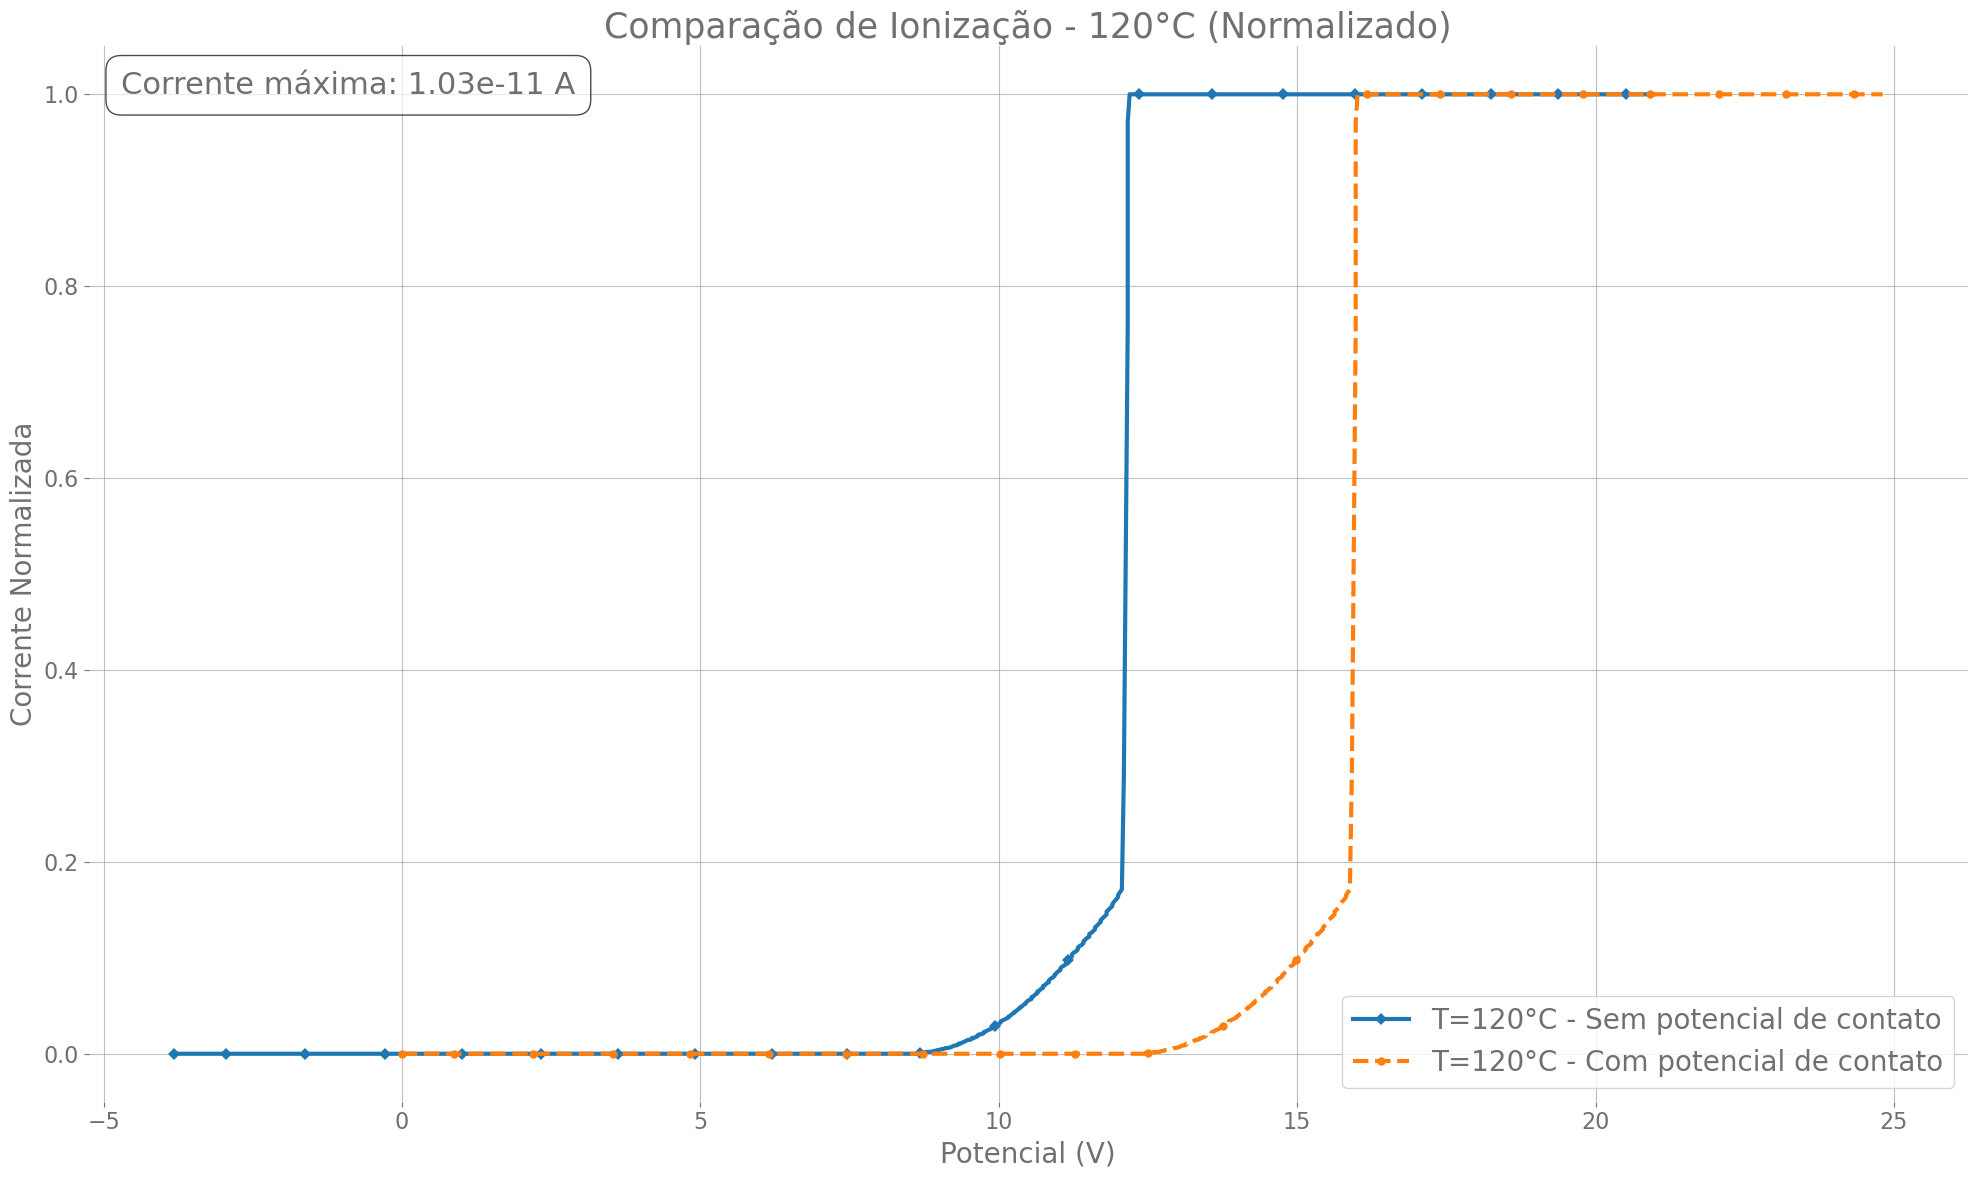

(      Potencial (V)  Corrente (uA)  Corrente Normalizada
 0          -3.82000        0.00000                   0.0
 1          -3.82000        0.00000                   0.0
 2          -3.82000        0.00000                   0.0
 3          -3.82000        0.00000                   0.0
 4          -3.82000        0.00000                   0.0
 ...             ...            ...                   ...
 1019       20.92496        0.00001                   1.0
 1020       20.92496        0.00001                   1.0
 1021       20.95718        0.00001                   1.0
 1022       20.98940        0.00001                   1.0
 1023       20.98940        0.00001                   1.0
 
 [1024 rows x 3 columns],
       Potencial (V)  Corrente (uA)  Corrente Normalizada
 0           0.00000        0.00000                   0.0
 1           0.00000        0.00000                   0.0
 2           0.00000        0.00000                   0.0
 3           0.00000        0.00000         

In [44]:
plot_comparacao_deslocamento(
    temperatura=120,
    pasta_dados="Dados experimentais 23.10.2025 (Com fator de escala)/",
    pasta_excel="/home/joliveira/Documents/franck-hertz/",
    salvar=True,
    pasta_saida="/home/joliveira/Documents/franck-hertz/Resultados/"
)


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def plot_todas_ionizacoes(pasta_dados, pasta_excel, salvar=False, pasta_saida=None):
    """
    Lê e plota as medidas de ionização para as temperaturas 110, 120, 130 e 140°C,
    todas normalizadas pelo valor máximo global de corrente.
    """

    temperaturas = [110, 120, 130, 140]
    cores = ['red', 'blue', 'green', 'orange']
    marcadores = ['o', 's', 'D', 'x']

    dados_temp = {}
    maximos = {}

    # --- Ler e processar cada temperatura ---
    for T in temperaturas:
        nome_arquivo_dados = f"m1-i-T_{T}.txt"
        nome_arquivo_excel = f"Medidas Ionização {T}°C (Com fator de escala).xlsx"

        caminho_dados = os.path.join(pasta_dados, nome_arquivo_dados)
        caminho_excel = os.path.join(pasta_excel, nome_arquivo_excel)

        if not os.path.isfile(caminho_excel):
            raise FileNotFoundError(f"Arquivo Excel não encontrado: {caminho_excel}")
        if not os.path.isfile(caminho_dados):
            raise FileNotFoundError(f"Arquivo de dados não encontrado: {caminho_dados}")

        # Ler Excel e extrair escala
        df_excel = pd.read_excel(caminho_excel)
        df_excel.columns = [str(c).strip() for c in df_excel.columns]
        escala_col = next((c for c in df_excel.columns if "escala" in c.lower()), None)
        if escala_col is None:
            raise KeyError(f"Coluna 'Escala' não encontrada no arquivo {caminho_excel}")
        escala = pd.to_numeric(df_excel[escala_col], errors="coerce").dropna().iloc[0]

        # Ler dados experimentais
        df = pd.read_csv(
            caminho_dados,
            sep=r"\s+",
            header=None,
            names=["Potencial (V)", "Corrente (uA)"],
            engine="python"
        )
        df["Potencial (V)"] = pd.to_numeric(df["Potencial (V)"].astype(str).str.replace(",", "."), errors="coerce")
        df["Corrente (uA)"] = pd.to_numeric(df["Corrente (uA)"].astype(str).str.replace(",", "."), errors="coerce")
        df = df.dropna()

        # Aplicar fator de escala
        df["Corrente (uA)"] *= escala
        maximos[T] = df["Corrente (uA)"].max()
        dados_temp[T] = df

    # --- Determinar o maior valor global ---
    T_max = max(maximos, key=maximos.get)
    I_max_global = maximos[T_max]
    I_max_amp = I_max_global * 1e-6  # converter µA → A

    # --- Plotar todas as curvas normalizadas ---
    for T, cor, marcador in zip(temperaturas, cores, marcadores):
        df = dados_temp[T]
        df["Corrente Normalizada"] = df["Corrente (uA)"] / I_max_global
        # plt.yscale('log')
        plt.plot(
            df["Potencial (V)"],
            df["Corrente Normalizada"],
            linestyle="-",
            marker=marcador,
            markersize=6,
            markerfacecolor=cor,
            markeredgewidth=0,
            markevery=50,
            color=cor,
            label=f"{T}°C"
        )



    # --- Anotação do valor máximo ---
    plt.annotate(
        f"Corrente máxima: {I_max_amp:.2e} (A)",
        xy=(0.01, 0.99),
        xycoords="axes fraction",
        xytext=(10, -10),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=20,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7)
    )

    # --- Finalizar gráfico ---
    plt.title("Medidas de Ionização (110–140°C) - Normalizadas pelo Máximo Global")
    plt.xlabel("Potencial (V)")
    plt.ylabel("Corrente Normalizada")
    plt.grid(True, linestyle="-", alpha=0.6)
    plt.legend(title="Temperaturas", loc="lower right")
    plt.tight_layout()

    # --- Salvar se solicitado ---
    if salvar:
        if pasta_saida is None:
            raise ValueError("É necessário fornecer 'pasta_saida' quando salvar=True.")
        os.makedirs(pasta_saida, exist_ok=True)
        caminho_saida = os.path.join(pasta_saida, "Ionizacao_Todas.png")
        plt.savefig(caminho_saida, dpi=300)
        print(f"✅ Gráfico salvo em: {caminho_saida}")

    plt.show()


✅ Gráfico salvo em: Resultados/Ionizacao_Todas.png


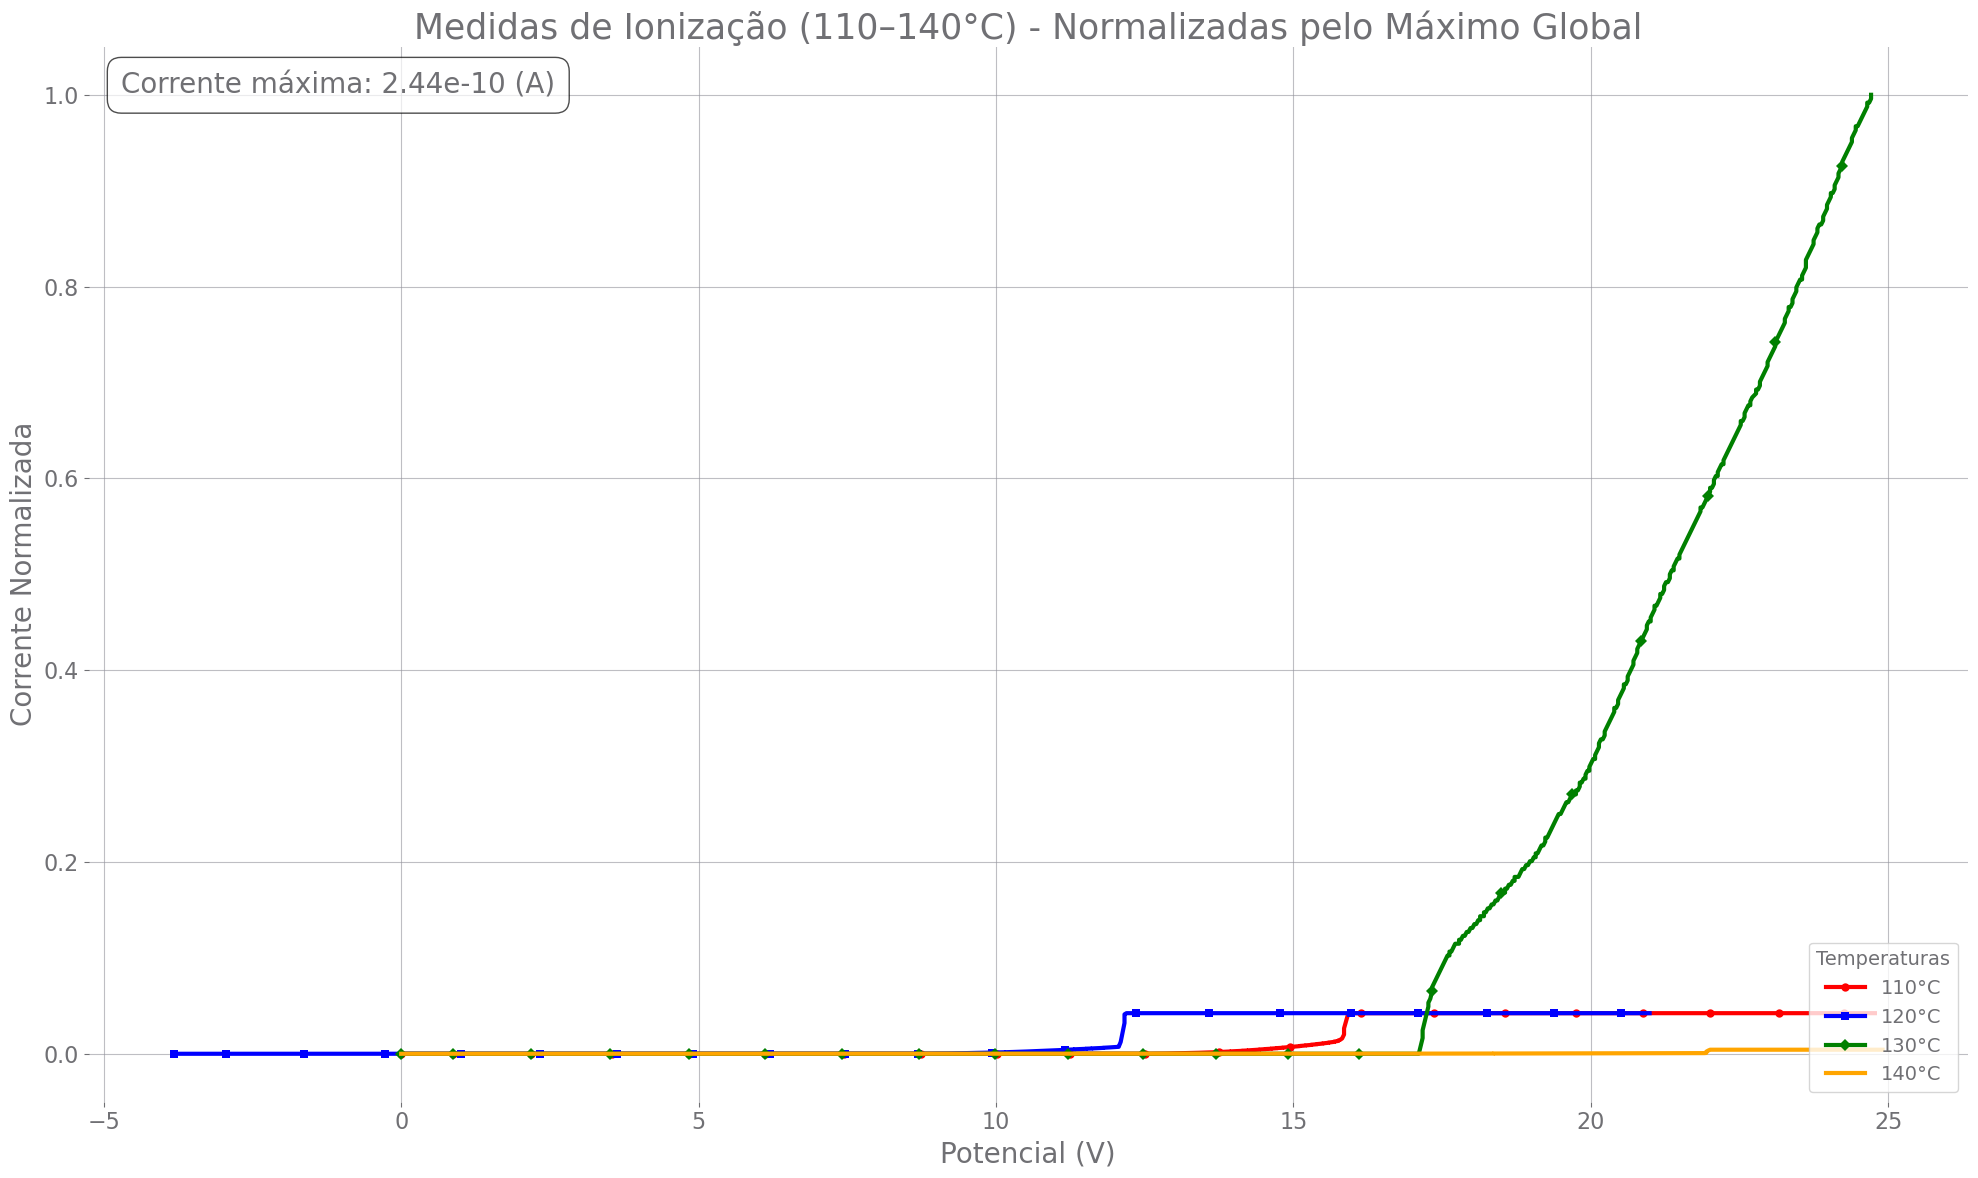

In [46]:
plot_todas_ionizacoes(
    pasta_dados="Dados experimentais 23.10.2025 (Com fator de escala)/",
    pasta_excel="/home/joliveira/Documents/franck-hertz/",
    salvar=True,
    pasta_saida="Resultados/"
)
